<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8_EOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Laboratoire d'Attaques Adversariales sur YOLOv8, Expectation Over Transformation

In [20]:
!pip install ultralytics torch torchvision pillow matplotlib opencv-python

In [21]:
import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Choix du device (CUDA 13 / GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda


In [22]:
def print_detections(yolo_results, model_names, title="Résultats de détection"):
    """
    Affiche proprement de manière textuelle toutes les bounding boxes,
    les classes et les scores de confiance détectés par YOLO.
    """
    print(f"\n--- {title} ---")

    boxes = yolo_results[0].boxes
    if len(boxes) == 0:
        print("🎯 Aucune détection (le modèle est complètement aveuglé !)")
        return

    for box in boxes:
        cls_id = int(box.cls[0].item())
        cls_name = model_names[cls_id]
        conf = box.conf[0].item()

        # Récupération des coordonnées [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = [int(coord) for coord in box.xyxy[0].tolist()]

        print(f"Objet : {cls_name} | Confiance : {conf:.2f} | Box : [{x1}, {y1}, {x2}, {y2}]")

Image prête, normalisée et enregistrée sous : bus_640.jpg

image 1/1 /content/bus_640.jpg: 640x640 4 persons, 1 bus, 7.7ms
Speed: 0.9ms preprocess, 7.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


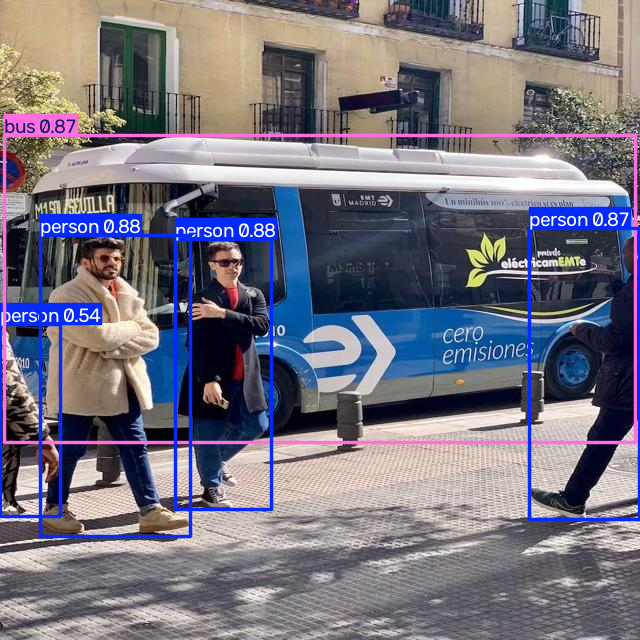


--- Détections YOLO avant application de patchs ---
Objet : person | Confiance : 0.88 | Box : [40, 235, 190, 536]
Objet : person | Confiance : 0.88 | Box : [175, 239, 271, 509]
Objet : person | Confiance : 0.87 | Box : [529, 228, 639, 519]
Objet : bus | Confiance : 0.87 | Box : [4, 135, 635, 442]
Objet : person | Confiance : 0.54 | Box : [0, 324, 60, 516]


In [23]:
# Chargement du modèle nano pré-entraîné
model = YOLO("yolov8n.pt")
model.model.to(device)

from ultralytics.utils.downloads import safe_download
import os

# 1. Télécharger l'image d'origine si elle n'existe pas
raw_image_path = "bus.jpg"
if not os.path.exists(raw_image_path):
    safe_download("https://ultralytics.com/images/bus.jpg", dir=".")

# 2. ⚡ NORMALISATION DIRECTE EN 640x640
# Cela garantit un format parfait pour les couches de YOLO et fixe vos coordonnées x,y
pil_img = Image.open(raw_image_path).convert("RGB").resize((640, 640))
image_path = "bus_640.jpg"
pil_img.save(image_path)

print(f"Image prête, normalisée et enregistrée sous : {image_path}")

# 3. Affichage de la prédiction d'origine sur l'image normalisée
results = model(image_path)
results[0].show()
print_detections(results, model.names, title="Détections YOLO avant application de patchs")




In [24]:
def apply_patch(image_path, patch_tensor, patch_coords):
    """
    Colle un patch de pixels (patch_tensor) sur l'image
    aux coordonnées exactes (x_min, y_min, x_max, y_max).
    """
    pil_img = Image.open(image_path).convert("RGB")
    to_tensor = transforms.ToTensor()
    to_pil = transforms.ToPILImage()

    img_tensor = to_tensor(pil_img).to(device)
    x_min, y_min, x_max, y_max = patch_coords

    img_tensor[:, y_min:y_max, x_min:x_max] = patch_tensor
    return to_pil(img_tensor.cpu())

In [25]:
# 1. Définition de la taille et de la position du patch (entre les deux personnes, au niveau du ventre/bassin)
patch_h, patch_w = 100, 100
x = 100  # Ajustez selon vos coordonnées exactes
y = 350
patch_coords = (x, y, x + patch_w, y + patch_h)


image 1/1 /content/temp_patched_image.jpg: 640x640 5 persons, 1 bus, 19.4ms
Speed: 1.1ms preprocess, 19.4ms inference, 4.9ms postprocess per image at shape (1, 3, 640, 640)


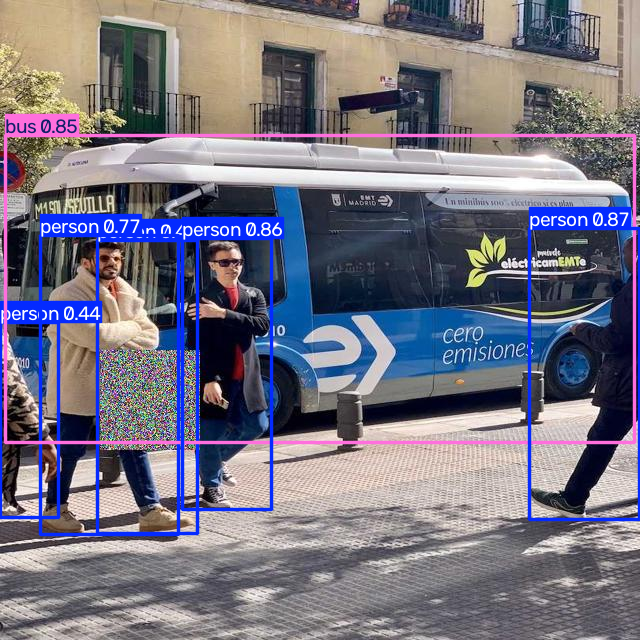


--- Détections YOLO après patch bruit aléatoire ---
Objet : person | Confiance : 0.87 | Box : [529, 228, 639, 519]
Objet : person | Confiance : 0.86 | Box : [182, 238, 271, 509]
Objet : bus | Confiance : 0.85 | Box : [5, 135, 634, 442]
Objet : person | Confiance : 0.77 | Box : [40, 235, 178, 534]
Objet : person | Confiance : 0.44 | Box : [0, 322, 58, 517]
Objet : person | Confiance : 0.42 | Box : [97, 240, 197, 533]


In [26]:
# 2. Création d'un patch de bruit initial (aléatoire pur entre 0 et 1)
adversarial_patch = torch.rand(3, patch_h, patch_w, device=device)

# 3. Application du patch aléatoire sur l'image normalisée
modified_image = apply_patch(image_path, adversarial_patch, patch_coords)

# 4. Sauvegarde temporaire et analyse par YOLO
temp_path = "temp_patched_image.jpg"
modified_image.save(temp_path)

rand_patched_results = model(temp_path)
rand_patched_results[0].show()

# 5. Extraction textuelle des détections
print_detections(rand_patched_results, model.names, title="Détections YOLO après patch bruit aléatoire")

In [27]:
import torch.optim as optim

model.model.train()

pil_img = Image.open(image_path).convert("RGB")
orig_tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

adversarial_patch = torch.rand(3, patch_h, patch_w, device=device, requires_grad=True)
optimizer = optim.Adam([adversarial_patch], lr=0.05)
num_iterations = 500  # On met un peu plus d'itérations pour un vrai impact

print("🚀 Lancement de l'optimisation ciblée sur la classe 'Personne'...")

for iteration in range(num_iterations):
    optimizer.zero_grad()

    # A. EOT (Expectation Over Transformation)
    noise = torch.randn_like(orig_tensor, device=device) * 0.02
    eot_img = torch.clamp(orig_tensor + noise, 0.0, 1.0)

    # B. Incrustation
    x_min = min(x, 640 - patch_w)
    y_min = min(y, 640 - patch_h)
    x_max, y_max = x_min + patch_w, y_min + patch_h

    patched_img = eot_img.clone()
    patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

    # C. Prédiction brute
    preds = model.model(patched_img)

    # D. Extraction et Loss ciblée
    if isinstance(preds, dict):
        tensor_preds = list(preds.values())[0]
    elif isinstance(preds, (list, tuple)):
        tensor_preds = preds[0]
    else:
        tensor_preds = preds

    # On cible la minimisation de la confiance (on veut que le score de présence baisse)
    loss = torch.mean(torch.sigmoid(tensor_preds))

    # E. Rétropropagation
    loss.backward()
    optimizer.step()

    # F. Clamp physique
    with torch.no_grad():
        adversarial_patch.clamp_(0.0, 1.0)

    if (iteration + 1) % 100 == 0 or iteration == 0:
        print(f"Itération {iteration + 1}/{num_iterations} - Loss : {loss.item():.6f}")

print("✨ Optimisation ciblée terminée !")

🚀 Lancement de l'optimisation ciblée sur la classe 'Personne'...
Itération 1/500 - Loss : 0.599230
Itération 100/500 - Loss : 0.597618
Itération 200/500 - Loss : 0.597428
Itération 300/500 - Loss : 0.597406
Itération 400/500 - Loss : 0.597380
Itération 500/500 - Loss : 0.597283
✨ Optimisation ciblée terminée !



image 1/1 /content/temp_optimized_target.jpg: 640x640 4 persons, 1 bus, 7.8ms
Speed: 0.9ms preprocess, 7.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


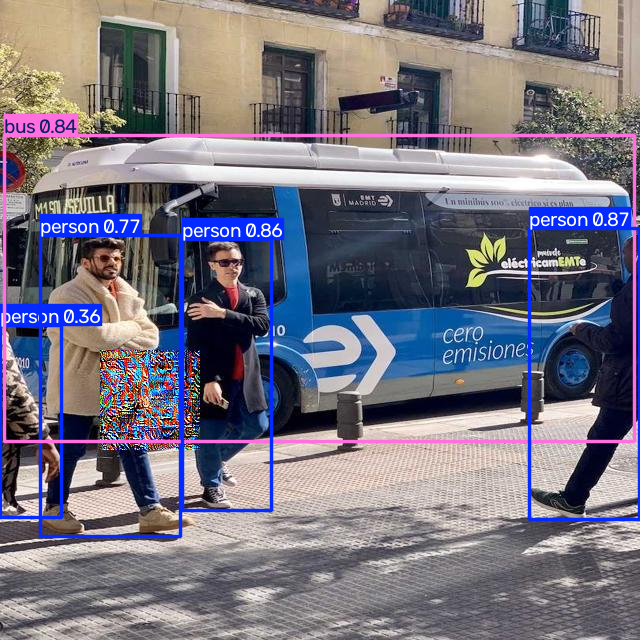


--- Détections YOLO après patch EOM ---
Objet : person | Confiance : 0.87 | Box : [529, 228, 639, 519]
Objet : person | Confiance : 0.86 | Box : [182, 239, 271, 510]
Objet : bus | Confiance : 0.84 | Box : [4, 135, 634, 441]
Objet : person | Confiance : 0.77 | Box : [40, 235, 180, 536]
Objet : person | Confiance : 0.36 | Box : [0, 325, 61, 517]


In [32]:
# 1. Application du patch optimisé
final_patched_img = orig_tensor.clone()
x_min = min(x, 640 - patch_w)
y_min = min(y, 640 - patch_h)
x_max, y_max = x_min + patch_w, y_min + patch_h

final_patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

# 2. Conversion et test avec YOLO (en mode inférence normal)
to_pil = transforms.ToPILImage()
result_pil_img = to_pil(final_patched_img.squeeze(0).cpu())
temp_optimized_path = "temp_optimized_target.jpg"
result_pil_img.save(temp_optimized_path)

eom_patched_results = model(temp_optimized_path)
eom_patched_results[0].show()

# 3. Rapport des scores
print_detections(eom_patched_results, model.names, title="Détections YOLO après patch EOM")

In [29]:
def compare_detections(baseline_results, patched_results, model_names, iou_threshold=0.3):
    """
    Compare deux jeux de résultats YOLO (baseline vs patché) en se basant
    sur les coordonnées des boîtes (IoU) pour suivre chaque objet individuellement.
    """
    def compute_iou(box1, box2):
        # box: [x1, y1, x2, y2]
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        inter_area = max(0, x2 - x1) * max(0, y2 - y1)
        if inter_area == 0:
            return 0.0

        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union_area = area1 + area2 - inter_area

        return inter_area / union_area if union_area > 0 else 0.0

    base_boxes = baseline_results[0].boxes
    patch_boxes = patched_results[0].boxes

    print("\n" + "="*70)
    print("🔍 RAPPORT D'ANALYSE COMPARATIF DES ATTAQUES ADVERSARIALES")
    print("="*70)

    matched_patch_indices = set()

    # 1. Analyse des objets de la baseline et leur évolution
    for i, b_box in enumerate(base_boxes):
        b_cls = model_names[int(b_box.cls[0].item())]
        b_conf = b_box.conf[0].item()
        b_coords = [int(c) for c in b_box.xyxy[0].tolist()]

        best_match_idx = -1
        max_iou = 0.0

        # Trouver la boîte correspondante dans les résultats patchés via l'IoU
        for j, p_box in enumerate(patch_boxes):
            if j in matched_patch_indices:
                continue
            p_cls = model_names[int(p_box.cls[0].item())]
            if p_cls == b_cls:
                p_coords = [int(c) for c in p_box.xyxy[0].tolist()]
                iou = compute_iou(b_coords, p_coords)
                if iou > max_iou:
                    max_iou = iou
                    best_match_idx = j

        if max_iou >= iou_threshold and best_match_idx != -1:
            matched_patch_indices.add(best_match_idx)
            p_box = patch_boxes[best_match_idx]
            p_conf = p_box.conf[0].item()
            p_coords = [int(c) for c in p_box.xyxy[0].tolist()]

            diff = p_conf - b_conf
            if diff < -0.05:
                status = f"📉 Baisse de confiance ({diff:+.2f})"
            elif diff > 0.05:
                status = f"📈 Hausse de confiance ({diff:+.2f})"
            else:
                status = "⚖️ Stable"

            print(f"[Objet Retrouvé] {b_cls}")
            print(f"   Origine : Conf = {b_conf:.2f} | Box = {b_coords}")
            print(f"   Patché  : Conf = {p_conf:.2f} | Box = {p_coords}")
            print(f"   Statut  : {status}\n")
        else:
            print(f"[❌ DISPARITION / ÉCHEC] {b_cls}")
            print(f"   L'objet initial (Conf = {b_conf:.2f}, Box = {b_coords}) a disparu ou sa boîte a trop muté.\n")

    # 2. Détection des nouveaux objets apparus (ex: fausses détections type 'handbag')
    for j, p_box in enumerate(patch_boxes):
        if j not in matched_patch_indices:
            p_cls = model_names[int(p_box.cls[0].item())]
            p_conf = p_box.conf[0].item()
            p_coords = [int(c) for c in p_box.xyxy[0].tolist()]
            print(f"[✨ NOUVEL OBJET APPARU (Artefact)] {p_cls}")
            print(f"   Détecté avec Conf = {p_conf:.2f} | Box = {p_coords}\n")

    print("="*70)

In [33]:
compare_detections(results, eom_patched_results, model.names)


🔍 RAPPORT D'ANALYSE COMPARATIF DES ATTAQUES ADVERSARIALES
[Objet Retrouvé] person
   Origine : Conf = 0.88 | Box = [40, 235, 190, 536]
   Patché  : Conf = 0.77 | Box = [40, 235, 180, 536]
   Statut  : 📉 Baisse de confiance (-0.12)

[Objet Retrouvé] person
   Origine : Conf = 0.88 | Box = [175, 239, 271, 509]
   Patché  : Conf = 0.86 | Box = [182, 239, 271, 510]
   Statut  : ⚖️ Stable

[Objet Retrouvé] person
   Origine : Conf = 0.87 | Box = [529, 228, 639, 519]
   Patché  : Conf = 0.87 | Box = [529, 228, 639, 519]
   Statut  : ⚖️ Stable

[Objet Retrouvé] bus
   Origine : Conf = 0.87 | Box = [4, 135, 635, 442]
   Patché  : Conf = 0.84 | Box = [4, 135, 634, 441]
   Statut  : ⚖️ Stable

[Objet Retrouvé] person
   Origine : Conf = 0.54 | Box = [0, 324, 60, 516]
   Patché  : Conf = 0.36 | Box = [0, 325, 61, 517]
   Statut  : 📉 Baisse de confiance (-0.17)



In [31]:
import torch.optim as optim

model.model.train()

pil_img = Image.open(image_path).convert("RGB")
orig_tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

# 1. Calcul des coordonnées exactes
x_min = min(x, 640 - patch_w)
y_min = min(y, 640 - patch_h)
x_max, y_max = x_min + patch_w, y_min + patch_h

# 2. EXTRACTION DES PIXELS D'ORIGINE : Le patch commence exactement comme le vêtement !
# Au tout début (itération 0), le patch est 100% invisible.
original_patch_pixels = orig_tensor[:, :, y_min:y_max, x_min:x_max].clone().detach()
adversarial_patch = original_patch_pixels.clone().detach().requires_grad_(True)

optimizer = optim.Adam([adversarial_patch], lr=0.05)
num_iterations = 500

print("🚀 Lancement de l'optimisation furtive (partie des pixels réels)...")

for iteration in range(num_iterations):
    optimizer.zero_grad()

    # A. EOT (Expectation Over Transformation)
    noise = torch.randn_like(orig_tensor, device=device) * 0.02
    eot_img = torch.clamp(orig_tensor + noise, 0.0, 1.0)

    # B. Incrustation du patch sur l'image
    patched_img = eot_img.clone()
    patched_img[:, :, y_min:y_max, x_min:x_max] = adversarial_patch

    # C. Passage dans le modèle
    preds = model.model(patched_img)

    # D. Extraction et Loss
    if isinstance(preds, dict):
        tensor_preds = list(preds.values())[0]
    elif isinstance(preds, (list, tuple)):
        tensor_preds = preds[0]
    else:
        tensor_preds = preds

    loss = torch.mean(torch.sigmoid(tensor_preds))

    # E. Rétropropagation
    loss.backward()
    optimizer.step()

    # F. Sécurité physique (valeurs entre 0 et 1)
    with torch.no_grad():
        adversarial_patch.clamp_(0.0, 1.0)

    if (iteration + 1) % 100 == 0 or iteration == 0:
        print(f"Itération {iteration + 1}/{num_iterations} - Loss : {loss.item():.6f}")

print("✨ Optimisation furtive terminée !")

🚀 Lancement de l'optimisation furtive (partie des pixels réels)...
Itération 1/500 - Loss : 0.599470
Itération 100/500 - Loss : 0.597705
Itération 200/500 - Loss : 0.597719
Itération 300/500 - Loss : 0.597466
Itération 400/500 - Loss : 0.597641
Itération 500/500 - Loss : 0.597313
✨ Optimisation furtive terminée !
